In [1]:
%matplotlib inline
import sys
import os
import time
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

To speed up things we parallelize the code

# Parameters

In [2]:
# parameters
def a_m(m,b): return (8*np.sqrt(2)/np.pi) * ((m**2)/(4*m**2 - 1)) * ((b**2 + m**2 -1)/(b**2 + m**2))

def b_m(m,b,beta): return (beta*b**2)/(b**2 + m**2)

def d_m(m,b): return (64*np.sqrt(2)/(15*np.pi)) * ((b**2 - m**2 +1)/(b**2 + m**2))
    
def g_m_tilde(m,b,gamma): return gamma * ((4*m)/(4*m**2 -1)) * (b*np.sqrt(2)/np.pi)

e = 16*np.sqrt(2)/(5*np.pi)

def g_m(m,b,gamma): return gamma * ((4*m**3)/(4*m**2 -1)) * (b*np.sqrt(2)/(np.pi*(b**2 + m**2)))

In [3]:
x_1_star = 0.95
x_4_star = -0.76095
C = 0.1 
gamma = 0.2
beta = 1.25
b = 1.6
s = 0.05

a_1, a_2, b_1, b_2 = a_m(1,b), a_m(2,b), b_m(1,b,beta), b_m(2,b,beta)
d_1, d_2 = d_m(1,b), d_m(2,b)
g_1_tilde, g_2_tilde = g_m_tilde(1,b,gamma), g_m_tilde(2,b,gamma)
g_1, g_2 = g_m(1,b,gamma), g_m(2,b,gamma)
F1 = C*x_1_star
F4 = C*x_4_star

# Averages on the fly: Parallel implementation

In [4]:
from scipy.stats import skew
from scipy.stats import kurtosis

### Unforced ensemble
def CvD_model_parallel_avgOnTheFly(x_0, 
                                   F1, F4, C, 
                                   a_1, a_2, 
                                   b_1, b_2, 
                                   d_1, d_2, 
                                   g_1_tilde, g_2_tilde, 
                                   g_1, g_2, e, s,
                                   dt, N, rand_seed=123):

    rng = np.random.default_rng(rand_seed)
    Nens = x_0.shape[0]
    x = x_0.copy()
    
    avg_x = np.zeros([N, 6])
    var_x = np.zeros([N, 6])
    
    for t in range(N):
        avg_x[t] = np.mean(x, axis=0)
        var_x[t] = np.var(x, axis=0)
        
        wiener = rng.normal(0, 1, (Nens, 6)) * np.sqrt(dt)
        
        x_prev = x.copy()  # snapshot for simultaneous updates

        x[:,0] = x_prev[:,0] + (F1 - C*x_prev[:,0] + g_1_tilde*x_prev[:,2])*dt + s*wiener[:,0]
        x[:,1] = x_prev[:,1] + (-C*x_prev[:,1] + b_1*x_prev[:,2] - a_1*x_prev[:,0]*x_prev[:,2] - d_1*x_prev[:,3]*x_prev[:,5])*dt + s*wiener[:,1]
        x[:,2] = x_prev[:,2] + (-C*x_prev[:,2] - b_1*x_prev[:,1] + a_1*x_prev[:,0]*x_prev[:,1] + d_1*x_prev[:,3]*x_prev[:,4] - g_1*x_prev[:,0])*dt + s*wiener[:,2]
        x[:,3] = x_prev[:,3] + (F4 - C*x_prev[:,3] + e*x_prev[:,1]*x_prev[:,5] - e*x_prev[:,2]*x_prev[:,4] + g_2_tilde*x_prev[:,5])*dt + s*wiener[:,3]
        x[:,4] = x_prev[:,4] + (-C*x_prev[:,4] + b_2*x_prev[:,5] - a_2*x_prev[:,0]*x_prev[:,5] - d_2*x_prev[:,3]*x_prev[:,2])*dt + s*wiener[:,4]
        x[:,5] = x_prev[:,5] + (-C*x_prev[:,5] - b_2*x_prev[:,4] + a_2*x_prev[:,0]*x_prev[:,4] + d_2*x_prev[:,3]*x_prev[:,1] - g_2*x_prev[:,3])*dt + s*wiener[:,5]

    return avg_x, var_x

# Impulse response functions

In [5]:
x_1_star = 0.95
x_4_star = -0.76095
C = 0.1 
gamma = 0.2
beta = 1.25
b = 1.6
s = 0.05

a_1, a_2, b_1, b_2 = a_m(1,b), a_m(2,b), b_m(1,b,beta), b_m(2,b,beta)
d_1, d_2 = d_m(1,b), d_m(2,b)
g_1_tilde, g_2_tilde = g_m_tilde(1,b,gamma), g_m_tilde(2,b,gamma)
g_1, g_2 = g_m(1,b,gamma), g_m(2,b,gamma)
F1 = C*x_1_star
F4 = C*x_4_star

## Forcing to save

In [7]:
CdV_trajectory = np.load('./results/CdV_long_trajectory.npy')

In [8]:
CdV_trajectory.shape

(100000001, 6)

In [ ]:
np.std(CdV_trajectory)

In [26]:
# Compute forcing term
# This is the forcing term
dt = 0.01
period_long = 4000
t_array = np.linspace(dt, period_long*dt, period_long)
forcing = np.zeros([period_long,6])
for t in range(period_long):
    t_n = t_array[t]
    forcing[t] = np.array([0.,0.26570756,0.,0.,0.,0.])

In [27]:
np.save('./results_responses_step/forcing_term.npy',forcing)

## Compute changes of mean and variance to impulse perturbations

In [28]:
%%time

period_long = 4000 # This is Model Time Unit (MTI) = 50

# Number of ensemble members
N_ens = 10**5 #10000000
dt = 0.01

'''
Let us sample initial conditions directly from the attractor. 
To do so, we consider a long integration of the system and random sample 
an ensemble of initial conditions from it
'''

# Load the long trajectory, but keep only the first 10^7 points
long_trajectory = np.load('./results/CdV_long_trajectory.npy')#[0:10**7]

# Consider N_ens initial conditions
# I have N_ens indices going from 0 to the length of the trajectory
idx = np.random.randint(0, len(long_trajectory),N_ens)

# We here considering these initial conditions equispaces
#n_steps = long_trajectory.shape[0]
# Equally spaced indices between 0 and n_steps-1
#idx = np.linspace(0, n_steps - 1, N_ens, dtype=int)
x_0 = long_trajectory[idx]

########## Ensemble of control simulations on the attractor
    
# Initial condition
init_cond = x_0

# Generate a random seed (or set it manually for reproducibility)
rand_seed_c = np.random.randint(0, 2**32 - 1)  # Random seed
C_avg_x, C_var_x = CvD_model_parallel_avgOnTheFly(init_cond, 
                         F1, F4, C, 
                         a_1, a_2, 
                         b_1, b_2, 
                         d_1, d_2, 
                         g_1_tilde, g_2_tilde, 
                         g_1, g_2, e, s,
                    dt,period_long,rand_seed = rand_seed_c)

########## Ensemble of perturbed simulations on the attractor

P_avg_x, P_var_x = CvD_model_parallel_avgOnTheFly_with_Step(init_cond, 
                         F1, F4, C, 
                         a_1, a_2, 
                         b_1, b_2, 
                         d_1, d_2, 
                         g_1_tilde, g_2_tilde, 
                         g_1, g_2, e, s,
                    dt,period_long,rand_seed = rand_seed_c)

# Note, I am using the same seed as the control run

CPU times: user 4min 13s, sys: 1.79 s, total: 4min 15s
Wall time: 4min 20s


In [29]:
# Response in the mean
R_mean = (P_avg_x-C_avg_x)
R_var = (P_var_x-C_var_x)

In [30]:
np.save('./results_responses_step/response_mean.npy',R_mean)
np.save('./results_responses_step/response_var.npy',R_var)

In [32]:
R_mean[1]

array([0.        , 0.00265708, 0.        , 0.        , 0.        ,
       0.        ])

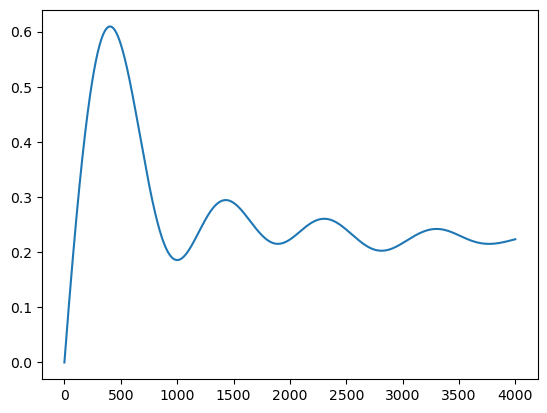

In [33]:
time = 4000
k = 1
plt.plot(R_mean[0:time,k])

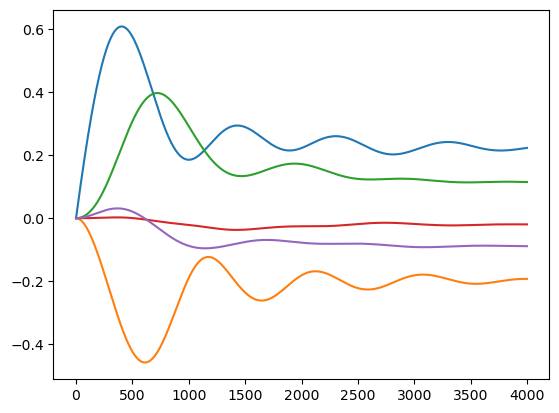

In [34]:
time = 4000
#k = 0
#plt.plot(R_mean[0:time,k])
k = 1
plt.plot(R_mean[0:time,k])
k = 2
plt.plot(R_mean[0:time,k])
k = 3
plt.plot(R_mean[0:time,k])
k = 4
plt.plot(R_mean[0:time,k])
k = 5
plt.plot(R_mean[0:time,k])

In [ ]:
time = 4000
k = 1
plt.plot(R_var[0:time,k])

In [ ]:
time = 4000
k = 1
plt.plot(R_var[0:time,k])